# RLSF — scoring the register trajectory (val, CPU)

---
## 1 — Preconditions

In [20]:
%cd /home/prnamhr/projects/Style-Aware-MT
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import yaml

from src.eval.heldout_decomp import CELLS, STEPS, TRAJ_DIR, traj_condition

PY = sys.executable
COMET_PY = '.venv-comet/bin/python'
SPLIT = 'val'

# The arms in pre-registration order; CELLS carries the same three, keyed by cell.
ARMS = {'RL-Metric': 'w3_0.0', 'RLSF-Judge': 'w3_2.0', 'RLSF-Judge-High': 'w3_6.0'}
TRAJ_CONDS = [traj_condition(cell, step) for cell in CELLS for step in STEPS]
ANCHORS = ['peft', *CELLS.values()]
print(f'{len(TRAJ_CONDS)} ladder points over steps {STEPS}, {len(ANCHORS)} anchors in outputs/')

/home/prnamhr/projects/Style-Aware-MT
15 ladder points over steps [100, 200, 400, 800, 1200], 4 anchors in outputs/


In [21]:
from pathlib import Path

if not Path('manage.py').exists():
    if not Path('Style-Aware-MT/manage.py').exists():
        !git clone https://github.com/prnamhr/Style-Aware-MT.git
    %cd Style-Aware-MT
!git pull --ff-only
!git rev-parse --short HEAD

Already up to date.
81ce2b4


In [22]:
VAL = [json.loads(x) for x in open(f'data/splits/{SPLIT}.jsonl') if x.strip()]
MANIFEST = json.loads((TRAJ_DIR / 'manifest.json').read_text(encoding='utf-8'))

# The condition field in these records is inherited from the eval config and reads 'peft'
# throughout; provenance is carried by arm/step/adapter, and that is what is checked here.
FILES = {}
for cell in CELLS:
    for step in STEPS:
        path = TRAJ_DIR / f'{traj_condition(cell, step)}_{SPLIT}.jsonl'
        rows = [json.loads(x) for x in path.open(encoding='utf-8') if x.strip()]
        assert len(rows) == len(VAL), f'{path}: {len(rows)} rows, expected {len(VAL)}'
        assert all(a['input'] == b['input'] for a, b in zip(rows, VAL)), f'{path}: misaligned'
        assert not [r for r in rows if r.get('error') or not r['prediction'].strip()], path
        assert {(r['arm'], r['step']) for r in rows} == {(cell, step)}, f'{path}: mixed provenance'
        entry = MANIFEST['checkpoints'][f'{cell}_step{step}']
        assert {r['adapter'] for r in rows} == {entry['adapter']}, f'{path}: adapter disagrees'
        FILES[(cell, step)] = [r['prediction'] for r in rows]

digests = [MANIFEST['checkpoints'][f'{c}_step{s}']['sha256'] for c in CELLS for s in STEPS]
assert len(set(digests)) == len(digests), 'two ladder points were written by the same weights'
print(f'{len(FILES)} files x {len(VAL)} aligned segments, {len(set(digests))} distinct adapters')

15 files x 1323 aligned segments, 15 distinct adapters


In [23]:
# A trajectory point is comparable to a reported arm only if it was decoded the same way.
GEN = MANIFEST['generator']
assert (GEN['temperature'], GEN['top_p'], GEN['seed']) == (0.0, 1.0, 42), GEN
assert GEN['dtype'] == 'bfloat16' and not GEN['load_in_4bit'], GEN

for cell in CELLS:
    cfg = yaml.safe_load(Path(f'configs/rlsf_eval_{cell}.yaml').read_text())['generator']
    shared = {k: cfg[k] for k in ('model', 'max_tokens', 'temperature', 'top_p', 'seed', 'dtype')}
    assert shared == {k: GEN[k] for k in shared}, (cell, shared)
print(f"ladder and arms share the decoding: greedy, seed {GEN['seed']}, {GEN['dtype']}")

ladder and arms share the decoding: greedy, seed 42, bfloat16


---
## 2 — The noise floor

In [24]:
from sacrebleu.metrics import CHRF

from src.eval.heldout_decomp import _feature_matrix, decompose, paired_delta, z_draws
from src.eval.stylometrics import HELDOUT_FEATURES, SPLIT_FEATURES, subcentroid

N_BOOT, ALPHA, SEED = 10000, 0.05, 42
CENTROID = json.loads(Path('results/stylometrics_centroid_split.json').read_text(encoding='utf-8'))
FULL = subcentroid(CENTROID, SPLIT_FEATURES)
HELD_COLS = [SPLIT_FEATURES.index(name) for name in HELDOUT_FEATURES]
MARKER_COL = SPLIT_FEATURES.index('marker_rate')
IDX = np.random.default_rng(SEED).integers(0, len(VAL), size=(N_BOOT, len(VAL)))


def register(texts):
    """Point held-out distance, signed z, and the paired bootstrap draws of the distance."""
    matrix = _feature_matrix(texts, SPLIT_FEATURES)
    mean, std = np.asarray(FULL['mean']), np.asarray(FULL['std'])
    z = dict(zip(SPLIT_FEATURES, ((matrix.mean(axis=0) - mean) / std).tolist()))
    draws = z_draws(matrix, FULL, IDX)
    return {
        'dist_heldout': decompose(z, HELDOUT_FEATURES)['dist'],
        'z': z,
        'dist_draws': np.linalg.norm(draws[:, HELD_COLS], axis=1),
        'z_marker_draws': draws[:, MARKER_COL],
    }

In [25]:
SELECTED = {
    cell: json.loads(Path(f'results/rlsf_select_{cell}.json').read_text(encoding='utf-8'))['selected']
    for cell in CELLS
}
REFS = [r['output'] for r in VAL]
chrf = CHRF()

print(f"{'cell':8s} {'step':>5s} {'identical':>10s} {'arm dist':>9s} {'ladder':>8s} "
      f"{'delta':>8s} {'ci95':>18s} {'arm chrF':>9s} {'ladder':>7s}")
NOISE = {}
for cell, tag in SELECTED.items():
    step = int(tag.removeprefix('step'))
    arm = [json.loads(x)['prediction'] for x in open(f'outputs/rlsf_{cell}_{SPLIT}.jsonl')]
    ladder = FILES[(cell, step)]
    a, b = register(arm), register(ladder)
    d = paired_delta(b['dist_draws'], a['dist_draws'], ALPHA)
    NOISE[cell] = d
    identical = sum(1 for x, y in zip(arm, ladder) if x == y) / len(arm)
    print(f'{cell:8s} {step:5d} {identical:9.1%} {a["dist_heldout"]:9.4f} {b["dist_heldout"]:8.4f} '
          f'{d["delta"]:+8.4f} [{d["ci_low"]:+.4f}, {d["ci_high"]:+.4f}] '
          f'{chrf.corpus_score(arm, [REFS]).score:9.2f} {chrf.corpus_score(ladder, [REFS]).score:7.2f}')

FLOOR = max(abs(d['delta']) for d in NOISE.values())
print(f'\nlargest matched-checkpoint discrepancy {FLOOR:.4f} in held-out distance: any trajectory '
      f'movement of that size or below is not distinguishable from session noise.')

cell      step  identical  arm dist   ladder    delta               ci95  arm chrF  ladder
w3_0.0     200     69.2%    0.1802   0.1815  +0.0012 [-0.0089, +0.0112]     41.85   41.98
w3_2.0     200     70.8%    0.2133   0.2112  -0.0022 [-0.0174, +0.0124]     42.04   42.15
w3_6.0     100     68.9%    0.1912   0.1773  -0.0136 [-0.0277, -0.0001]     42.08   42.13

largest matched-checkpoint discrepancy 0.0136 in held-out distance: any trajectory movement of that size or below is not distinguishable from session noise.


---
## 3 — Adequacy along the ladder

In [26]:
!{PY} manage.py eval --conditions {' '.join(TRAJ_CONDS)} --split {SPLIT} --out_dir {TRAJ_DIR}

condition             n     BLEU   chrF   marker_rate  ref_marker_rate
----------------------------------------------------------------------
rlsf_w3_0.0_step100   1323  16.91  41.68  0.92         0.79           
rlsf_w3_0.0_step200   1323  17.31  41.98  0.92         0.79           
rlsf_w3_0.0_step400   1323  17.55  42.24  0.92         0.79           
rlsf_w3_0.0_step800   1323  18.34  42.69  0.94         0.79           
rlsf_w3_0.0_step1200  1323  18.67  42.9   0.91         0.79           
rlsf_w3_2.0_step100   1323  17.06  42.04  0.95         0.79           
rlsf_w3_2.0_step200   1323  17.0   42.15  1.0          0.79           
rlsf_w3_2.0_step400   1323  17.23  42.43  1.03         0.79           
rlsf_w3_2.0_step800   1323  17.98  43.1   1.14         0.79           
rlsf_w3_2.0_step1200  1323  17.85  43.24  1.22         0.79           
rlsf_w3_6.0_step100   1323  17.12  42.13  0.93         0.79           
rlsf_w3_6.0_step200   1323  16.97  42.25  0.99         0.79           
rlsf_w

In [27]:
# The anchors: the initialization every arm started from, and the three reported arms.
!{PY} manage.py eval --conditions {' '.join(ANCHORS)} --split {SPLIT}

condition    n     BLEU   chrF   marker_rate  ref_marker_rate
-------------------------------------------------------------
peft         1323  16.9   41.58  0.92         0.79           
rlsf_w3_0.0  1323  17.01  41.85  0.93         0.79           
rlsf_w3_2.0  1323  17.0   42.04  0.99         0.79           
rlsf_w3_6.0  1323  17.13  42.08  0.95         0.79           


In [28]:
from src.eval.quick import score

SURFACE = {(cell, step): score(traj_condition(cell, step), TRAJ_DIR, SPLIT)
           for cell in CELLS for step in STEPS}
INIT = score('peft', Path('outputs'), SPLIT)

# Corpus chrF and BLEU, the aggregates the selection rule ranks on. Section 5 recomputes both
# per segment so they can be bootstrapped; these are the numbers that reading is checked against.
x = np.log2(np.asarray(STEPS, dtype=float) / STEPS[0])
xc = x - x.mean()
for metric in ('chrF', 'BLEU'):
    print(f"{metric:8s} " + ' '.join(f'{s:>8d}' for s in STEPS))
    for cell in CELLS:
        y = [SURFACE[(cell, s)][metric] for s in STEPS]
        print(f'{cell:8s} ' + ' '.join(f'{v:8.2f}' for v in y))
    print(f'  initialization (peft) {metric} {INIT[metric]:.2f}\n')
print('the adequacy band from the selection rule is 1.0 chrF below the best checkpoint on dev.')

chrF          100      200      400      800     1200
w3_0.0      41.68    41.98    42.24    42.69    42.90
w3_2.0      42.04    42.15    42.43    43.10    43.24
w3_6.0      42.13    42.25    42.61    42.74    42.77
  initialization (peft) chrF 41.58

BLEU          100      200      400      800     1200
w3_0.0      16.91    17.31    17.55    18.34    18.67
w3_2.0      17.06    17.00    17.23    17.98    17.85
w3_6.0      17.12    16.97    17.31    17.24    16.95
  initialization (peft) BLEU 16.90

the adequacy band from the selection rule is 1.0 chrF below the best checkpoint on dev.


In [29]:
# COMET gets its own interpreter: requirements-comet.txt pins transformers and numpy below what
# the generator stack uses. Scored per arm so a kernel death costs one arm, not the ladder.
if not Path(COMET_PY).exists():
    pip = [COMET_PY, '-m', 'pip', 'install', '-q']
    subprocess.run([PY, '-m', 'venv', '.venv-comet'], check=True)
    subprocess.run([*pip, '--upgrade', 'pip'], check=True)
    subprocess.run([*pip, 'setuptools<81'], check=True)
    subprocess.run([*pip, '-r', 'requirements-comet.txt'], check=True)

COMET_PATH = f'results/comet_traj_{SPLIT}.json'
for cell in CELLS:
    subprocess.run(
        [COMET_PY, 'manage.py', 'comet',
         '--conditions', *[traj_condition(cell, s) for s in STEPS],
         '--split', SPLIT, '--out_dir', str(TRAJ_DIR),
         '--results_path', COMET_PATH, '--batch_size', '16'],
        check=True,
    )

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 3670.84it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/home/prnamhr/projects/Style-Aware-MT/.venv-comet/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and ver

rlsf_w3_0.0_step100 COMET 0.7002  (n=1323)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/prnamhr/projects/Style-Aware-MT/.venv-comet/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


rlsf_w3_0.0_step200 COMET 0.7012  (n=1323)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/prnamhr/projects/Style-Aware-MT/.venv-comet/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

rlsf_w3_6.0_step400 COMET 0.7000  (n=1323)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/prnamhr/projects/Style-Aware-MT/.venv-comet/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


rlsf_w3_6.0_step800 COMET 0.6995  (n=1323)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/prnamhr/projects/Style-Aware-MT/.venv-comet/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


rlsf_w3_6.0_step1200 COMET 0.6990  (n=1323)
preserved 10 condition(s) not scored here: rlsf_w3_0.0_step100, rlsf_w3_0.0_step1200, rlsf_w3_0.0_step200, rlsf_w3_0.0_step400, rlsf_w3_0.0_step800, rlsf_w3_2.0_step100, rlsf_w3_2.0_step1200, rlsf_w3_2.0_step200, rlsf_w3_2.0_step400, rlsf_w3_2.0_step800
Wrote results/comet_traj_val.json


In [30]:
COMET = json.loads(Path(COMET_PATH).read_text(encoding='utf-8'))
ARM_COMET = json.loads(Path(f'results/comet_{SPLIT}.json').read_text(encoding='utf-8'))

# A ladder point is comparable to a reported arm only if the same COMET checkpoint scored both,
# on the same segments in the same order.
for cond, rec in COMET.items():
    assert rec['n'] == len(VAL), (cond, rec['n'])
    assert rec['model'] == ARM_COMET['peft']['model'], (cond, rec['model'])
    assert rec['sources'] == ARM_COMET['peft']['sources'], f'{cond}: segments are not paired'
assert set(COMET) == set(TRAJ_CONDS), set(TRAJ_CONDS) - set(COMET)

# COMET per doubling on the same log2 design as chrF and the register slopes.
COMET_SLOPE = {}
header = ' '.join(f'{s:>8d}' for s in STEPS)
print(f"{'cell':8s} {header}  {'arm':>8s} {'per doubling':>13s}")
for cell in CELLS:
    y = np.asarray([COMET[traj_condition(cell, s)]['system'] for s in STEPS])
    COMET_SLOPE[cell] = float((y - y.mean()) @ xc / (xc @ xc))
    print(f'{cell:8s} ' + ' '.join(f'{v:8.4f}' for v in y)
          + f"  {ARM_COMET[CELLS[cell]]['system']:8.4f} {COMET_SLOPE[cell]:+13.4f}")
print(f"\ninitialization (peft) COMET {ARM_COMET['peft']['system']:.4f}; the reward's adequacy "
      f"term was reference-free Kiwi, so this reference-based score is not what any arm maximized.")

cell          100      200      400      800     1200       arm  per doubling
w3_0.0     0.7002   0.7012   0.7032   0.7049   0.7056    0.7007       +0.0016
w3_2.0     0.7003   0.7001   0.7016   0.7030   0.7029    0.7007       +0.0009
w3_6.0     0.6999   0.6993   0.7000   0.6995   0.6990    0.6993       -0.0002

initialization (peft) COMET 0.6986; the reward's adequacy term was reference-free Kiwi, so this reference-based score is not what any arm maximized.


---
## 4 — Stylometrics

In [31]:
!{PY} manage.py stylometrics --conditions {' '.join(TRAJ_CONDS)} --split {SPLIT} \
    --out_dir {TRAJ_DIR} --targets-split train

label                 n      lex_density  lex_density_sd  ttr     ttr_sd  root_ttr  root_ttr_sd  sent_len_mean  sent_len_mean_sd  sent_len_var  sent_len_var_sd  marker_rate  marker_rate_sd  stylo_dist
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
target:train          10860  0.4344       0.1101          0.854   0.1085  4.0437    1.0426       24.7388        16.6125           6.6894        58.4011          0.0327       0.0567          0.0       
rlsf_w3_0.0_step100   1323   0.4091       0.1139          0.8537  0.1224  3.9381    1.029        25.1522        28.5483           3.7127        35.2069          0.0414       0.063           0.2947    
rlsf_w3_0.0_step200   1323   0.4093       0.1135          0.8542  0.1211  3.9361    1.022        24.9066        27.5629           3.3311        32.9356          0.0412       0.0632          0.2913

In [32]:
!{PY} manage.py stylometrics --conditions {' '.join(ANCHORS)} --split {SPLIT}

label        n     lex_density  lex_density_sd  ttr     ttr_sd  root_ttr  root_ttr_sd  sent_len_mean  sent_len_mean_sd  sent_len_var  sent_len_var_sd  marker_rate  marker_rate_sd  stylo_dist
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
peft         1323  0.4088       0.1118          0.8515  0.1229  3.9389    1.0278       25.4086        29.1189           3.6097        38.2494          0.0404       0.0621          0.2886    
rlsf_w3_0.0  1323  0.4086       0.1132          0.8543  0.1224  3.9392    1.0239       24.952         27.4353           3.6274        35.5306          0.0412       0.0633          0.296     
rlsf_w3_2.0  1323  0.407        0.1125          0.8528  0.1219  3.9546    1.0281       25.2423        27.7593           3.4383        33.6995          0.0438       0.0647          0.3279    
rlsf_w3_6.0  1323  0.4091       0.113        

---
## 5 — The trajectory

In [33]:
!{PY} manage.py heldout_decomp --trajectory --split {SPLIT} --n_resamples {N_BOOT} --seed {SEED}


Register trajectory across training  (split=val, n=1323 segments, resamples=10000, seed=42)
distance over ttr, root_ttr, marker_rate; deltas are against peft, which sits at dist 0.1707 and z(marker_rate) +0.1361.

cell    w3  step  dist    dist ci95           d vs peft  z marker  z ci95              dz vs peft  comet   comet ci95          dc vs peft  chrF   chrF ci95         dchrF vs peft  chrF corpus  BLEU   BLEU ci95         dBLEU vs peft  BLEU corpus
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
w3_0.0  0   100   0.1842  [+0.1330, +0.2487]  +0.0130    +0.1538   [+0.0971, +0.2133]  +0.0179*    0.7002  [+0.6945, +0.7057]  +0.0016*    40.35  [+39.51, +41.18]  +0.21          41.68        16.16  [+15.37, +16.98]  +0.13          16.91      
w3_0.0  0   200   0.1815  [+0.1297, +0.2470]  +0.0104

corpus chrF/BLEU in the report agree with section 3; the report's own columns are segment means


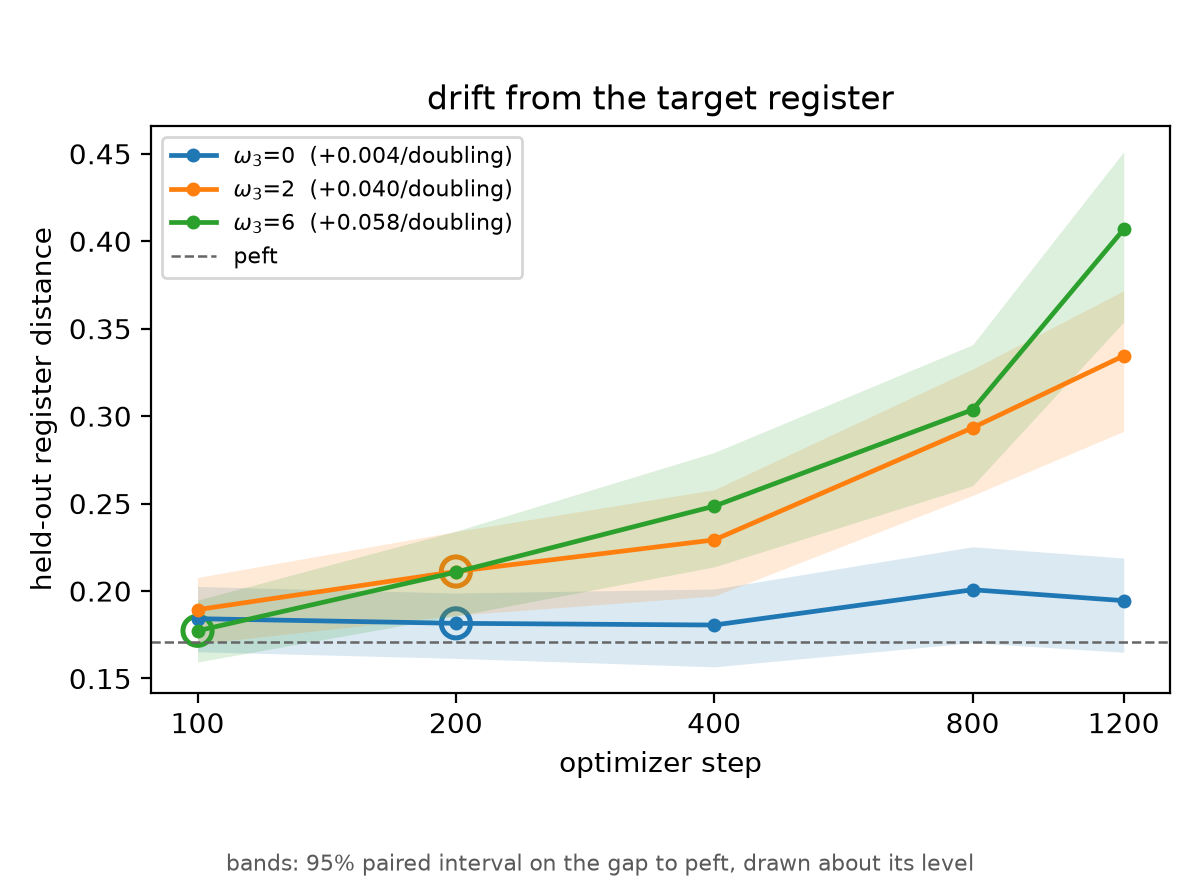

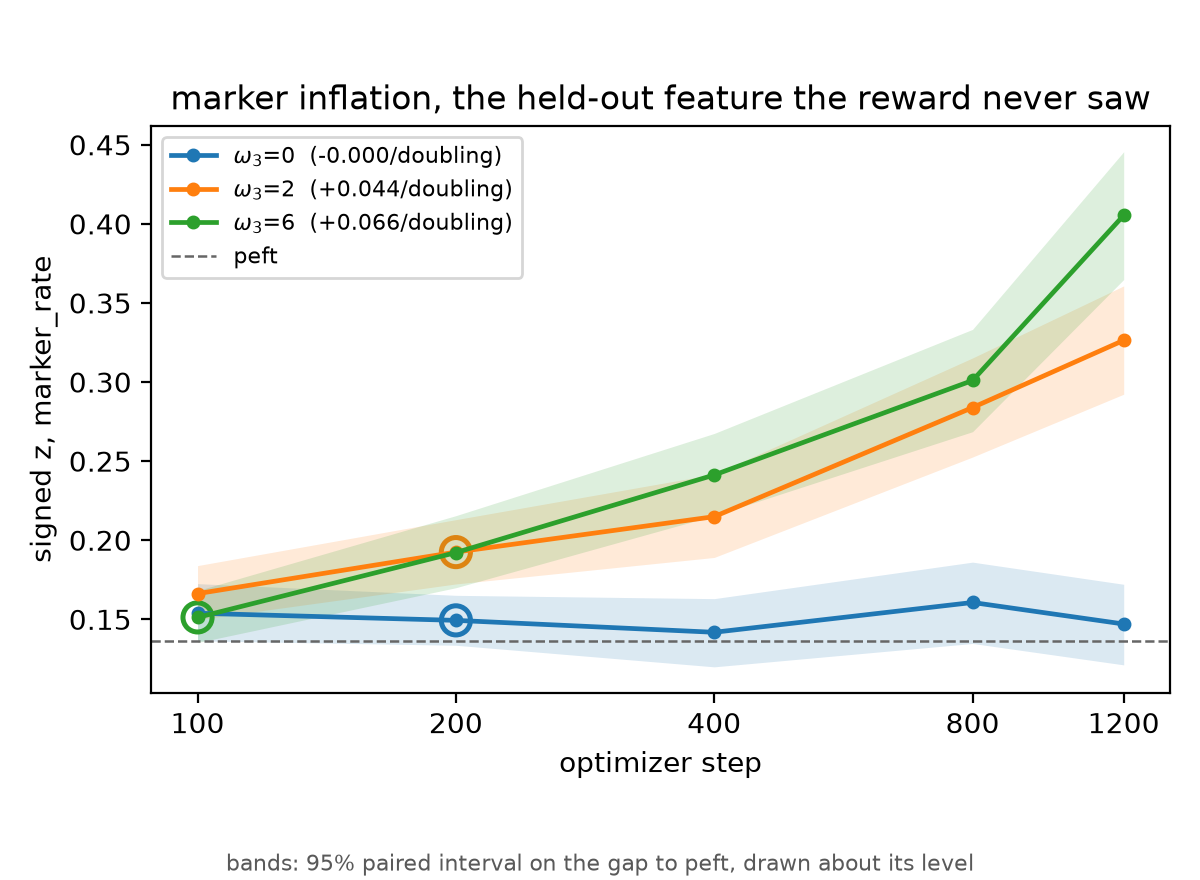

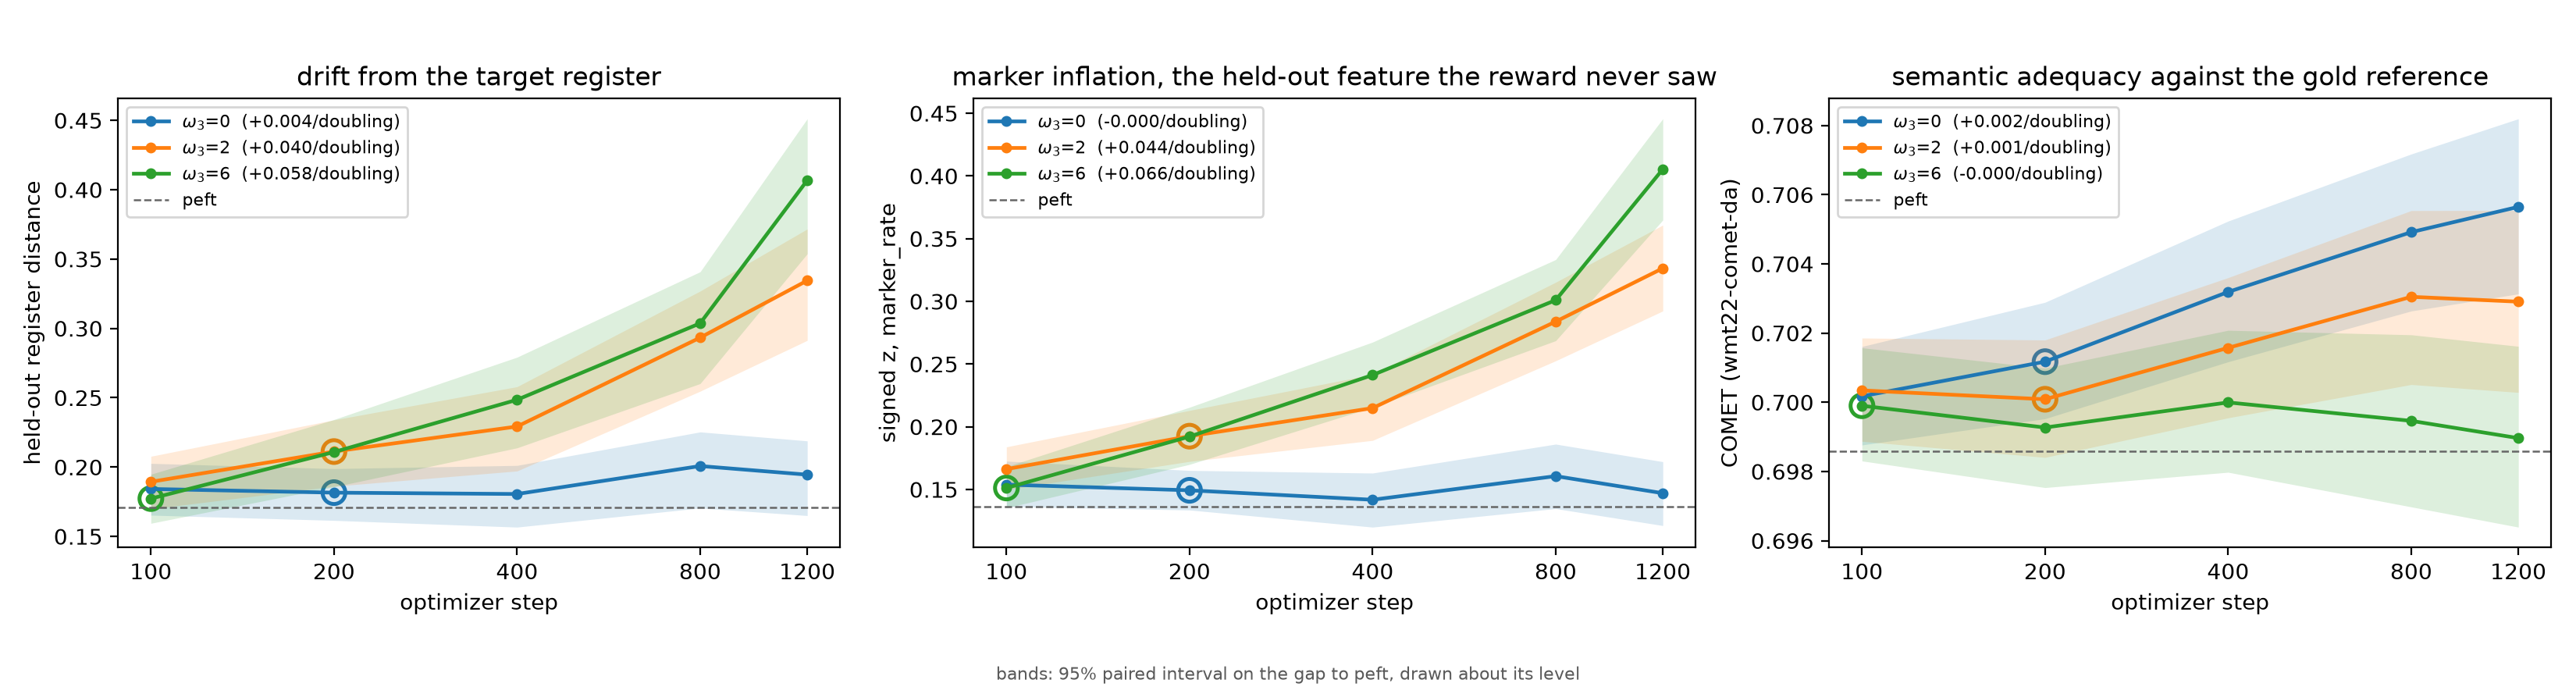

In [34]:
from IPython.display import Image, display

REPORT = json.loads(Path(f'results/heldout_traj_{SPLIT}.json').read_text(encoding='utf-8'))

# The corpus scores in the report must be the ones section 3 printed; a disagreement means the
# segment mean has been written into the column the selection rule reads.
for cell in REPORT['cells']:
    for row in REPORT['arms'][cell]['rows']:
        for metric, key in (('chrf', 'chrF'), ('bleu', 'BLEU')):
            assert row[f'{metric}_corpus'] == SURFACE[(cell, row['step'])][key], (cell, row['step'])
print(f"corpus chrF/BLEU in the report agree with section 3; the report's own columns are "
      f"{REPORT['surface']['aggregation']}s")

for path in ('docs/figures/traj_dist_heldout.png', 'docs/figures/traj_marker_rate_z.png'):
    display(Image(path))
Image('docs/figures/heldout_traj_by_step.png')

---
## 6 — Read-out

In [35]:
verdict = []
for q in REPORT['quantities']:
    rates = {cell: REPORT['arms'][cell]['growth'][q] for cell in REPORT['cells']}
    grew = [c for c, g in rates.items() if g['significant'] and g['slope_per_doubling'] > 0]
    ordered = REPORT['ordered_in_omega'][q]
    verdict.append(f'{q}: grows in {len(grew)}/{len(rates)} arms ({", ".join(grew) or "none"}); '
                   f'the three rates {"rank" if ordered else "do NOT rank"} in omega_3 order')
    for cell, g in rates.items():
        floor = abs(NOISE[cell]['delta']) if q == 'dist_heldout' else None
        note = '' if floor is None else \
            f'  (endpoint move {g["endpoint_delta"]["delta"]:+.4f} vs {floor:.4f} session noise)'
        verdict.append(f'   {cell}  {g["slope_per_doubling"]:+.4f} per doubling '
                       f'[{g["ci_low"]:+.4f}, {g["ci_high"]:+.4f}]  p={g["p_value"]:.4f}{note}')
print('\n'.join(verdict))

dist_heldout: grows in 2/3 arms (w3_2.0, w3_6.0); the three rates rank in omega_3 order
   w3_0.0  +0.0044 per doubling [-0.0035, +0.0112]  p=0.2524  (endpoint move +0.0097 vs 0.0012 session noise)
   w3_2.0  +0.0399 per doubling [+0.0290, +0.0495]  p=0.0000  (endpoint move +0.1431 vs 0.0022 session noise)
   w3_6.0  +0.0584 per doubling [+0.0449, +0.0698]  p=0.0000  (endpoint move +0.2266 vs 0.0136 session noise)
z_marker_rate: grows in 2/3 arms (w3_2.0, w3_6.0); the three rates rank in omega_3 order
   w3_0.0  -0.0001 per doubling [-0.0083, +0.0075]  p=0.9842
   w3_2.0  +0.0442 per doubling [+0.0345, +0.0536]  p=0.0000
   w3_6.0  +0.0656 per doubling [+0.0553, +0.0759]  p=0.0000
comet: grows in 2/3 arms (w3_0.0, w3_2.0); the three rates do NOT rank in omega_3 order
   w3_0.0  +0.0016 per doubling [+0.0010, +0.0022]  p=0.0000
   w3_2.0  +0.0009 per doubling [+0.0002, +0.0015]  p=0.0058
   w3_6.0  -0.0002 per doubling [-0.0008, +0.0005]  p=0.5960
chrf: grows in 3/3 arms (w3_0.0, w3_2.0

In [36]:
# T4, both axes on one row. Overoptimization of the proxy needs both halves: the held-out
# register distance climbing while adequacy does not fall with it, on every metric that measures it.
ADEQUACY = [q for q in ('comet', 'chrf', 'bleu') if q in REPORT['quantities']]


def verdict(g, falling='falls'):
    if not g['significant']:
        return 'holds'
    return falling if g['slope_per_doubling'] < 0 else 'rises'


print(f"{'cell':8s} {'register':>26s}  " +
      '  '.join(f'{q:>24s}' for q in ADEQUACY))
for cell in REPORT['cells']:
    reg = REPORT['arms'][cell]['growth']['dist_heldout']
    drift = 'grows' if reg['significant'] and reg['slope_per_doubling'] > 0 else 'flat'
    cols = []
    for q in ADEQUACY:
        g = REPORT['arms'][cell]['growth'][q]
        places = 4 if q == 'comet' else 2
        cols.append(f"{verdict(g):5s} {g['slope_per_doubling']:+.{places}f} "
                    f"[{g['ci_low']:+.{places}f}, {g['ci_high']:+.{places}f}]")
    print(f'{cell:8s} {drift:5s} {reg["slope_per_doubling"]:+.4f} '
          f'[{reg["ci_low"]:+.4f}, {reg["ci_high"]:+.4f}]  ' + '  '.join(f'{c:>24s}' for c in cols))

decoupled = [c for c in REPORT['cells']
             if REPORT['arms'][c]['growth']['dist_heldout']['significant']
             and REPORT['arms'][c]['growth']['dist_heldout']['slope_per_doubling'] > 0
             and all(REPORT['arms'][c]['growth'][q]['slope_per_doubling'] > 0
                     or not REPORT['arms'][c]['growth'][q]['significant'] for q in ADEQUACY)]
print(f"\nT4 holds in {len(decoupled)}/{len(REPORT['cells'])} arms ({', '.join(decoupled) or 'none'}): "
      f"register drift with no significant fall on {', '.join(ADEQUACY)}. Three metrics agreeing "
      f"on a null is stronger than one and is still a null.")

cell                       register                     comet                      chrf                      bleu
w3_0.0   flat  +0.0044 [-0.0035, +0.0112]  rises +0.0016 [+0.0010, +0.0022]  rises +0.29 [+0.18, +0.39]  rises +0.25 [+0.15, +0.36]
w3_2.0   grows +0.0399 [+0.0290, +0.0495]  rises +0.0009 [+0.0002, +0.0015]  rises +0.34 [+0.24, +0.44]  rises +0.19 [+0.08, +0.29]
w3_6.0   grows +0.0584 [+0.0449, +0.0698]  holds -0.0002 [-0.0008, +0.0005]  rises +0.15 [+0.05, +0.24]  holds -0.02 [-0.13, +0.08]

T4 holds in 2/3 arms (w3_2.0, w3_6.0): register drift with no significant fall on comet, chrf, bleu. Three metrics agreeing on a null is stronger than one and is still a null.


In [37]:
# The dev slice ranked the same checkpoints while selecting, on 499 segments the val files never
# saw. If dev and val disagree on the ordering, the val slopes are the ones to distrust.
print(f"{'cell':8s} {'dev slope':>10s} {'val slope':>10s} {'selected':>10s} {'chrF/doubling':>22s}")
for cell in REPORT['cells']:
    rows = {r['tag']: r for r in
            json.loads(Path(f'results/rlsf_select_{cell}.json').read_text(encoding='utf-8'))['rows']}
    y = np.asarray([rows[f'step{s}']['dist_heldout'] for s in STEPS])
    dev = float((y - y.mean()) @ xc / (xc @ xc))
    val = REPORT['arms'][cell]['growth']['dist_heldout']['slope_per_doubling']
    chrf = REPORT['arms'][cell]['growth']['chrf']
    print(f'{cell:8s} {dev:+10.4f} {val:+10.4f} {SELECTED[cell]:>10s} '
          f"{chrf['slope_per_doubling']:+9.3f} [{chrf['ci_low']:+.3f}, {chrf['ci_high']:+.3f}]")
print('\nThe selection rule saw the dev column, not the val one: an arm whose distance climbs '
      'fastest there is stopped earliest by a rule that ranks on that distance.')

cell      dev slope  val slope   selected          chrF/doubling
w3_0.0      +0.0062    +0.0044    step200    +0.288 [+0.182, +0.390]
w3_2.0      +0.0337    +0.0399    step200    +0.338 [+0.240, +0.439]
w3_6.0      +0.0535    +0.0584    step100    +0.147 [+0.051, +0.244]

The selection rule saw the dev column, not the val one: an arm whose distance climbs fastest there is stopped earliest by a rule that ranks on that distance.


---
## 7 — Seal

In [38]:
# Nothing here read the test split, and nothing here could spend: no rater, no API client.
for path in TRAJ_DIR.glob(f'*_{SPLIT}.jsonl'):
    assert 'test' not in path.name, path
assert not list(TRAJ_DIR.glob('*_usage.json')), 'a usage artefact means a paid call was made here'
print('0 paid calls, $0.00 spent\n')
print('written this pass:')
for p in (COMET_PATH, f'results/heldout_traj_{SPLIT}.json',
          'docs/figures/heldout_traj_by_step.png',
          'docs/figures/traj_dist_heldout.png', 'docs/figures/traj_marker_rate_z.png'):
    print(f'  {p}  {Path(p).stat().st_size / 1024:.1f} KiB')

0 paid calls, $0.00 spent

written this pass:
  results/comet_traj_val.json  8239.8 KiB
  results/heldout_traj_val.json  50.6 KiB
  docs/figures/heldout_traj_by_step.png  289.2 KiB
  docs/figures/traj_dist_heldout.png  117.2 KiB
  docs/figures/traj_marker_rate_z.png  122.0 KiB
